In [49]:
import torch
import matplotlib.pyplot as plt
from PIL import Image
import torchvision.transforms as T

### 1.对图片进行处理

<PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=1706x1279 at 0x1CBC18A0200>
(1706, 1279)


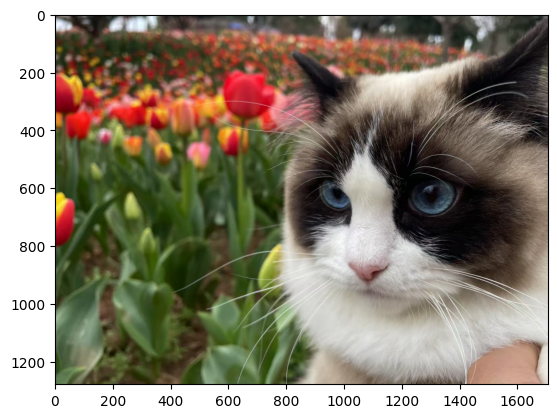

In [50]:
img = Image.open("./img/test_kaka.jpg")
print(img)
print(img.size)
# print(img.shape)
plt.imshow(img)

tensor([[[0.2863, 0.3529, 0.4431,  ..., 0.2667, 0.2431, 0.2431],
         [0.2745, 0.3333, 0.4157,  ..., 0.2980, 0.2667, 0.2627],
         [0.2824, 0.3059, 0.3608,  ..., 0.3647, 0.3412, 0.3333],
         ...,
         [0.3490, 0.3608, 0.3686,  ..., 0.8588, 0.8745, 0.8863],
         [0.3490, 0.3608, 0.3686,  ..., 0.8510, 0.8667, 0.8784],
         [0.3451, 0.3569, 0.3686,  ..., 0.8471, 0.8627, 0.8745]],

        [[0.2863, 0.3529, 0.4431,  ..., 0.2902, 0.2667, 0.2667],
         [0.2745, 0.3373, 0.4196,  ..., 0.3216, 0.2902, 0.2863],
         [0.2902, 0.3137, 0.3686,  ..., 0.3882, 0.3647, 0.3569],
         ...,
         [0.4588, 0.4706, 0.4784,  ..., 0.8235, 0.8392, 0.8510],
         [0.4588, 0.4706, 0.4784,  ..., 0.8196, 0.8353, 0.8431],
         [0.4549, 0.4667, 0.4784,  ..., 0.8118, 0.8275, 0.8392]],

        [[0.2902, 0.3529, 0.4471,  ..., 0.2745, 0.2510, 0.2510],
         [0.2549, 0.3176, 0.4000,  ..., 0.3059, 0.2745, 0.2706],
         [0.2471, 0.2706, 0.3255,  ..., 0.3725, 0.3490, 0.

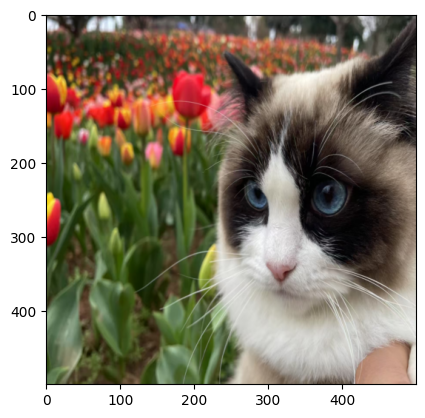

In [51]:
#图片处理
transform = T.Compose([
    T.Resize((500, 500)),
    T.ToTensor(),
])

img_tensor = transform(img)
print(img_tensor)
print(img_tensor.shape)
# plt.imshow()
img_numpy = img_tensor.permute(1, 2, 0).cpu().numpy()  #建议转换为numpy
plt.imshow(img_numpy)
print(img_numpy.shape)
print(type(img_numpy))

### 2.演示-自编码器-效果
#### 2.1 定义编码器模型

In [52]:
import torch.nn as nn


class AutoEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        # 编码器
        self.encoded = None
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(16, 8, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )
        # 解码器
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(8, 16, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(16, 3, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        encoded = self.encoder(x)
        self.encoded = encoded
        decoded = self.decoder(encoded)
        return decoded


# 测试
model = AutoEncoder()
input = torch.randn(1, 3, 256, 256)
# print(model)
output = model(input)
print(output.shape)

torch.Size([1, 3, 256, 256])


### 2.2 设置相关参数 (1.将模型移动到设备上 2.定义超参数 3.定义损失函数和优化器)

In [53]:
# 1.将模型移动到设备上
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
print(model)
# 2.定义超参数
lr = 1e-3
epoches = 200

# 3.定义损失函数和优化器
loss_f = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

AutoEncoder(
  (encoder): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (decoder): Sequential(
    (0): ConvTranspose2d(8, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (1): ReLU()
    (2): ConvTranspose2d(16, 3, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (3): Sigmoid()
  )
)


### 2.3 训练模型

In [54]:
def trainer(img_input,img_target):
    for epoch in range(epoches):
        model.train()
        input = img_input.to(device)
        target = img_target.to(device)

        output = model(input)
        loss_val = loss_f(output, target)
        loss_val.backward()

        optimizer.step()
        optimizer.zero_grad()

        if (epoch + 1) % 50 == 0:
            print(f"epoch:{epoch + 1}/{epoches},loss:{loss_val.item():.6f}")


trainer(img_tensor,img_tensor)

epoch:50/200,loss:0.052460
epoch:100/200,loss:0.011750
epoch:150/200,loss:0.007150
epoch:200/200,loss:0.005555


### 2.4 保存模型

In [55]:
torch.save(model.state_dict(), "./model/autoencoder.pth")

### 2.5测试训练图像

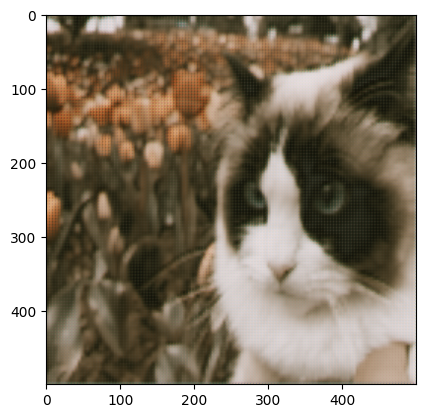

In [56]:
def test_img(img_test):
    with torch.no_grad():
        model.eval()
        input = img_test.to(device)
        output = model(input)
    img_numpy = output.detach().cpu().numpy()
    img_numpy = img_numpy.transpose((1, 2, 0))
    plt.imshow(img_numpy)
test_img(img_tensor)

### 3演示-去噪自编码器

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0007353425..1.4992802].


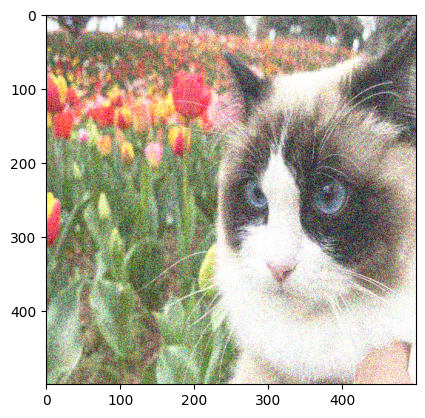

In [57]:
# 3.1加入噪声
img_noise = img_tensor + torch.rand_like(img_tensor) * 0.5
# 显示一下
img_numpy = img_noise.detach().permute(1, 2, 0).numpy()
plt.imshow(img_numpy)
plt.show()

epoch:50/200,loss:0.005452
epoch:100/200,loss:0.005094
epoch:150/200,loss:0.004835
epoch:200/200,loss:0.004594


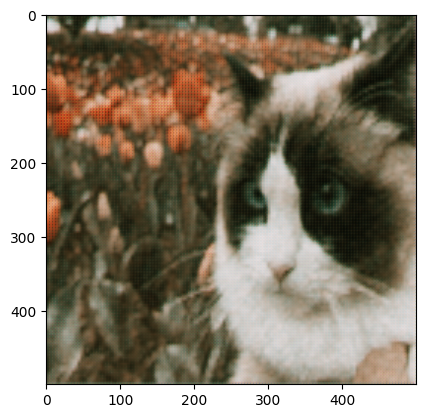

In [58]:
# 训练模型
trainer(img_noise,img_tensor)
# 测试结果
test_img(img_noise)